# Similitud Semantica y Modelado de Topicos

Ya tenemos un dataset de tweets sobre aerolineas, limpio y clasificado como Positivo, Neutral o Negativo. Hoy le hacemos dos preguntas mas:

1. **Similitud**: dado un comentario "ideal", ¿cuales son los tweets del dataset que mas se le parecen?
2. **Topicos**: dentro de todos los tweets negativos, ¿cuales son los principales temas de queja? ¿Es sobre todo el precio, el servicio, los retrasos?

La primera pregunta la respondemos con los vectores de spaCy que ya usamos antes. La segunda es una tecnica nueva: **LDA (Latent Dirichlet Allocation)**, un algoritmo de aprendizaje no supervisado que descubre temas dentro de una coleccion de textos, sin que nosotros le digamos de antemano cuales son esos temas.

## 0. Preparando el entorno

In [8]:
!pip install gensim # librería de NLP, especialmente mediante vectores de palabras y modelos de tópicos

In [9]:
!pip install spacy
!python -m spacy download en_core_web_lg

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.7/400.7 MB 4.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [10]:
import pandas as pd
import spacy
from gensim import corpora, models

## 1. Retomando el dataset

Cargamos el csv que guardamos al final del notebook anterior, y volvemos a cargar el modelo de spaCy (lo necesitamos para calcular vectores de nuevo; el csv no guarda los vectores, solo el texto).

In [11]:
df = pd.read_csv("feedback_aerolineas_sentimiento.csv")
nlp = spacy.load("en_core_web_lg")
df.head()

,id,sentimiento_original,razon_negativa,aerolinea,texto,texto_sentimiento,texto_topicos,sentimiento
0,570306133677760513,neutral,NaN,Virgin America,@VirginAmerica What @dhepburn said.,What said.,say,Neutral
1,570301130888122368,positive,NaN,Virgin America,@VirginAmerica plus you've added commercials t...,plus you've added commercials to the experienc...,plus add commercial experience tacky,Neutral
2,570301083672813571,neutral,NaN,Virgin America,@VirginAmerica I didn't today... Must mean I n...,I didn't today... Must mean I need to take ano...,today mean need trip,Negativo
3,570301031407624196,negative,Bad Flight,Virgin America,@VirginAmerica it's really aggressive to blast...,"it's really aggressive to blast obnoxious ""ent...",aggressive blast obnoxious entertainment guest...,Neutral
4,570300817074462722,negative,Can't Tell,Virgin America,@VirginAmerica and it's a really big bad thing...,and it's a really big bad thing about it,big bad thing,Negativo


## 2. Buscando los comentarios mas parecidos a uno "ideal"

Definamos como se veria un comentario ideal para una aerolinea, y busquemos, entre todos los tweets del dataset, cuales son los 5 mas parecidos en significado (no en palabras exactas).

In [12]:
comentario_ideal = nlp(
    "The flight was on time, the staff was kind and helpful, and everything went smoothly."
)

Ahora calculamos la similitud entre ese comentario ideal y cada tweet del dataset. Como son varios miles de tweets, usamos `nlp.pipe(...)` para procesarlos en lote de forma eficiente, igual que hicimos en el primer notebook de la semana.

In [13]:
similitudes = []
for doc in nlp.pipe(
    df["texto_sentimiento"],
    disable=["parser", "ner"], # No necesitamos estas partes para calcular la similitud
    batch_size=200): # Procesamos 200 comentarios a la vez para hacerlo mas eficiente
    similitudes.append(comentario_ideal.similarity(doc)) # Comparamos cada comentario con el comentario ideal

# El resultado es un numero: cuanto mas alto, mas similares son los textos
df["similitud_con_ideal"] = similitudes

/tmp/ipykernel_1176/3310940848.py:6: UserWarning: [W008] Evaluating Doc.similarity based on empty vectors.
  similitudes.append(comentario_ideal.similarity(doc)) # Comparamos cada comentario con el comentario ideal


In [14]:
top_5_parecidos = df.sort_values("similitud_con_ideal", ascending=False).head(5)

top_5_parecidos[["texto_sentimiento", "similitud_con_ideal", "sentimiento"]]

,texto_sentimiento,similitud_con_ideal,sentimiento
14000,"Thanks for the reply, but a functioning plane ...",0.948921,Positivo
11984,"Right. But more than two hours Late Flight, an...",0.942818,Negativo
12145,"Right. But more than two hours Late Flight, an...",0.942818,Negativo
10168,Thank you glad to be home. There were lots of ...,0.942207,Neutral
5501,"we had early bird, and it was great. Your empl...",0.941724,Positivo


In [15]:
top_5_parecidos["texto_sentimiento"].iloc[4]

'we had early bird, and it was great. Your employees were awesome. It was 3 passengers who killed the buzz.'

¿Los 5 tweets mas parecidos quedaron efectivamente clasificados como Positivo en la columna `sentimiento`? Es una buena forma de chequear, de manera cruzada, si nuestro clasificador de sentimiento y la busqueda por similitud estan mas o menos de acuerdo.

## 3. Modelado de topicos sobre los tweets negativos

Ahora nos quedamos solo con los tweets que **nosotros mismos** clasificamos como negativos en el notebook anterior, y usamos LDA para descubrir de que se quejan mas los clientes.

In [16]:
# Nos quedamos solamente con los tweets que TextBlob clasifico como negativos
negativos = df[df["sentimiento"] == "Negativo"].copy()

# Contamos cuantos tweets negativos tenemos
print("Cantidad de tweets negativos:", len(negativos))

Cantidad de tweets negativos: 2910


Para esto usamos la columna `texto_topicos` que armamos en el primer notebook de la semana: ya viene en minusculas, lematizada y sin stopwords, lista para este tipo de analisis. Gensim espera cada documento como una lista de palabras, asi que separamos el texto por espacios.

In [17]:
# Convertimos cada tweet en una lista de palabras
# fillna("") reemplaza posibles valores vacios por una cadena vacia
# str.split() separa el texto por espacios
# tolist() convierte la Serie de pandas en una lista de listas
textos_tokenizados = (
    negativos["texto_topicos"]
    .fillna("")
    .apply(str.split)
    .tolist()
)

textos_tokenizados[0]

['today', 'mean', 'need', 'trip']

### 3.1 Diccionario y corpus

Gensim necesita dos cosas: un `Dictionary` (que asigna un id a cada palabra distinta) y un `corpus`, donde cada documento se representa como una bolsa de palabras (cuantas veces aparece cada palabra, sin importar el orden).

De paso, sacamos del diccionario las palabras demasiado raras (que aparecen en muy pocos tweets) y las demasiado comunes (que aparecen en mas de la mitad de los tweets): ninguna de las dos ayuda a distinguir un topico de otro.

In [18]:
# Creamos un diccionario que asigna un ID a cada palabra del vocabulario
# Por ejemplo: "flight" -> 0, "delay" -> 1, "service" -> 2, ...
dictionary = corpora.Dictionary(textos_tokenizados)

print(dictionary[0])
print(dictionary.token2id)

mean
{'mean': 0, 'need': 1, 'today': 2, 'trip': 3, 'bad': 4, 'big': 5, 'thing': 6, '$': 7, '30': 8, 'flight': 9, 'fly': 10, 'pay': 11, 'playing': 12, 'seat': 13, 'seriously': 14, 'va': 15, '2a.': 16, '89': 17, 'answer': 18, 'expensive': 19, 'headphone': 20, 'help': 21, 'iad': 22, 'l&amp;f': 23, 'lax': 24, 'leave': 25, 'number': 26, 'await': 27, 'online': 28, 'option': 29, 'phone': 30, 'prefer': 31, 'return': 32, 'self': 33, 'service': 34, 'use': 35, 'andrews': 36, 'hand': 37, 'julie': 38, 'guyyyys': 39, 'heyyyy': 40, 'hour': 41, 'try': 42, 'cancel': 43, 'interesting': 44, 'planned.#neverflyvirginforbusiness': 45, 'business': 46, 'disappointing': 47, 'experience': 48, 'meet': 49, 'neverflyvirgin': 50, 'share': 51, 'traveler': 52, 'account': 53, 'add': 54, 'book': 55, 'elevate': 56, 'have': 57, 'trouble': 58, 'wife': 59, 'avatar': 60, 'bet': 61, 'disproportionate': 62, 'distribution': 63, 'kitty': 64, 'q': 65, 'random': 66, 'know': 67, 'rnp': 68, 'yeah': 69, 'disappointed': 70, 'flightle

In [19]:
# Eliminamos palabras demasiado raras o demasiado frecuentes
# no_below=5: la palabra debe aparecer en al menos 5 documentos
# no_above=0.5: eliminamos palabras que aparecen en mas del 50% de los documentos
dictionary.filter_extremes(no_below=5, no_above=0.5)

**Bag of Words (BoW)**

Bag of Words (BoW) es una forma sencilla de representar un texto como un conjunto de palabras y sus frecuencias.  

La idea es ignorar el orden de las palabras y quedarse únicamente con qué palabras aparecen y cuántas veces aparece cada una.

Ejemplo:


```
"the flight was late because the flight was delayed"
```

```
the      → 2
flight   → 2
was      → 2
late     → 1
because  → 1
delayed  → 1
```



In [20]:
# Convertimos cada documento a formato Bag of Words (BoW)
# Cada documento queda representado como pares (ID de palabra, cantidad de veces que aparece)
corpus = [dictionary.doc2bow(texto) for texto in textos_tokenizados]

## Veamos el primero BOW
primer_bow = corpus[0]

print(primer_bow)

[(0, 1), (1, 1), (2, 1), (3, 1)]


In [21]:
# Convertimos el BOW en palabras
for id_palabra, frecuencia in corpus[0]:
    print(dictionary[id_palabra], "→", frecuencia)

mean → 1
need → 1
today → 1
trip → 1


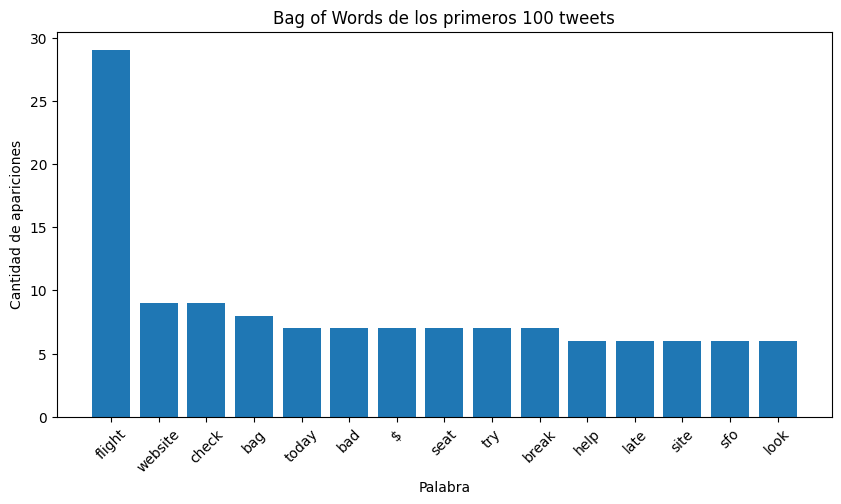

In [22]:
from collections import Counter
import matplotlib.pyplot as plt

# Combinamos las palabras de los primeros 100 tweets
todas_las_palabras = []

for texto in textos_tokenizados[:100]:
    todas_las_palabras.extend(texto)

# Contamos cuantas veces aparece cada palabra
frecuencias = Counter(todas_las_palabras)

# Nos quedamos con las 15 palabras mas frecuentes
top_palabras = frecuencias.most_common(15)

palabras = [palabra for palabra, frecuencia in top_palabras]
cantidades = [frecuencia for palabra, frecuencia in top_palabras]

plt.figure(figsize=(10, 5))
plt.bar(palabras, cantidades)

plt.xlabel("Palabra")
plt.ylabel("Cantidad de apariciones")
plt.title("Bag of Words de los primeros 100 tweets")

plt.xticks(rotation=45)
plt.show()

### 3.2 Entrenando el modelo LDA

LDA (Latent Dirichlet Allocation) es un modelo que permite descubrir automáticamente los temas principales presentes en un conjunto de documentos.

La idea es que:

- Cada documento puede hablar de varios temas.  
- Cada tema está caracterizado por un conjunto de palabras que suelen aparecer juntas.

Le pedimos al modelo que agrupe los tweets negativos en 3 topicos.

In [23]:
# Creamos un modelo LDA para descubrir automaticamente los temas presentes en los tweets

lda_model = models.LdaModel(
    corpus, # Documentos representados como Bag of Words
    num_topics=3, # Le pedimos al modelo que encuentre 3 temas
    id2word=dictionary, # Diccionario que permite convertir los IDs en palabras
    passes=10, # El modelo recorre el corpus 10 veces para aprender los temas
    random_state=42,
)



### 3.3 Leyendo los topicos encontrados

`print_topics()` nos muestra, para cada topico, las palabras que mas pesan, junto con su peso. Cuanto mas alto el peso, mas caracteristica es esa palabra de ese topico.

In [24]:
for idx, topico in lda_model.print_topics(num_words=8):
    print(f"Topico {idx}: {topico}")
    print()

Topico 0: 0.067*"bad" + 0.043*"service" + 0.036*"customer" + 0.026*"airline" + 0.020*"fly" + 0.019*"experience" + 0.016*"guy" + 0.013*"weather"

Topico 1: 0.017*"agent" + 0.015*"service" + 0.015*"2" + 0.013*"wait" + 0.013*"terrible" + 0.013*"gate" + 0.012*"phone" + 0.011*"amp"

Topico 2: 0.105*"flight" + 0.029*"hour" + 0.029*"late" + 0.028*"cancel" + 0.019*"delay" + 0.014*"plane" + 0.012*"time" + 0.012*"flightr"



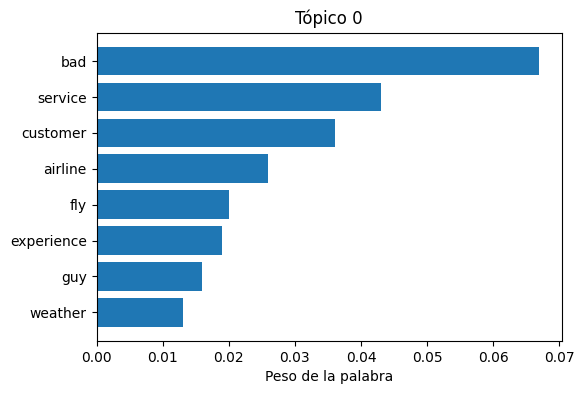

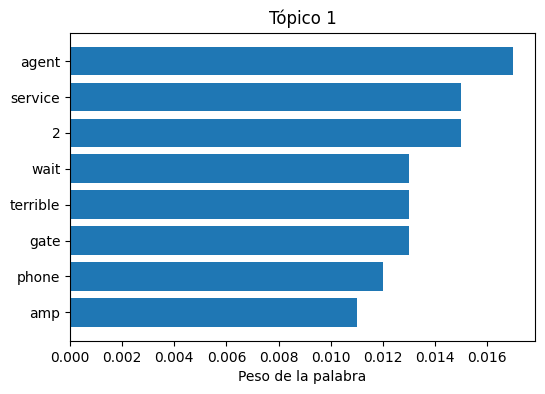

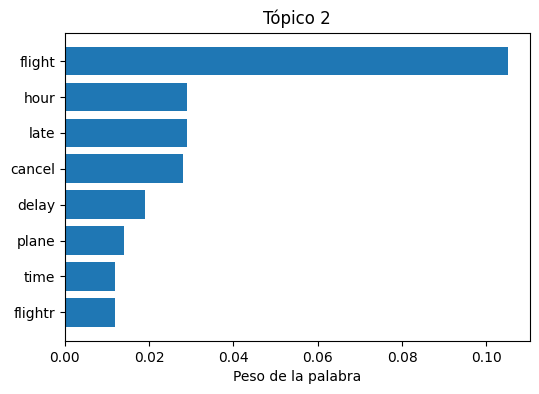

In [25]:
for idx, topico in lda_model.print_topics(num_words=8):

    # Convertimos el texto del topico en pares: palabra y peso
    palabras_pesos = [
        elemento.strip().split("*")
        for elemento in topico.split(" + ")
    ]

    # Extraemos las palabras y sus pesos
    palabras = [palabra.replace('"', "") for peso, palabra in palabras_pesos]
    pesos = [float(peso) for peso, palabra in palabras_pesos]

    # Creamos el grafico
    plt.figure(figsize=(6, 4))
    plt.barh(palabras[::-1], pesos[::-1])

    plt.xlabel("Peso de la palabra")
    plt.title(f"Tópico {idx}")
    plt.show()

### 4. Generando las nubes de palabras

`lda_model.show_topic(id, topn=...)` nos da, para un topico, una lista de tuplas (palabra, peso). `WordCloud` puede recibir directamente un diccionario de palabra a peso con `generate_from_frequencies`.

In [31]:
from wordcloud import WordCloud

fig, ejes = plt.subplots(1, 3, figsize=(18, 6))

for topico_id in range(3): # Recorremos los 3 topicos que aprendio el modelo LDA

    # Obtenemos las 30 palabras mas representativas del topico
    # y su peso dentro del topico
    pesos_palabras = dict(lda_model.show_topic(topico_id, topn=30))

    # Creamos una nube de palabras usando esos pesos
    # Las palabras con mayor peso apareceran mas grandes
    nube = WordCloud(
        width=600,
        height=400,
        background_color="white"
    ).generate_from_frequencies(pesos_palabras)

    # Mostramos la nube de palabras en el espacio correspondiente
    ejes[topico_id].imshow(nube, interpolation="bilinear")

    # Ponemos el nombre del topico
    ejes[topico_id].set_title(f"Topico {topico_id}")

    # Quitamos los ejes porque no necesitamos coordenadas
    ejes[topico_id].axis("off")


plt.tight_layout()
plt.show()

{'flight': np.float32(0.10543195),
 'hour': np.float32(0.029266711),
 'late': np.float32(0.028981578),
 'cancel': np.float32(0.028485816),
 'delay': np.float32(0.018864054),
 'plane': np.float32(0.013698722),
 'time': np.float32(0.0118186),
 'flightr': np.float32(0.011729708),
 'hold': np.float32(0.011515638),
 'get': np.float32(0.010501784),
 'flightle': np.float32(0.010181726),
 'wait': np.float32(0.010062219),
 'sit': np.float32(0.009728425),
 'minute': np.float32(0.008878359),
 'min': np.float32(0.008814286),
 'try': np.float32(0.008698301),
 'seat': np.float32(0.008567845),
 '$': np.float32(0.0083616255),
 'change': np.float32(0.008289251),
 'tell': np.float32(0.008264623),
 'help': np.float32(0.008172345),
 'bag': np.float32(0.007768068),
 '2': np.float32(0.0069395304),
 '4': np.float32(0.006834373),
 'day': np.float32(0.0067944564),
 'amp': np.float32(0.0067521185),
 'miss': np.float32(0.006699621),
 'leave': np.float32(0.0066611813),
 'phone': np.float32(0.006135197),
 'go': np

## 5. Nombrando los topicos

Miremos las palabras clave de cada topico y pongamosle un nombre analitico a cada uno (por ejemplo: "Cancelaciones y demoras", "Atencion al cliente", "Equipaje").

Anota tus 3 nombres aca:

- Topico 0:
- Topico 1:
- Topico 2:

### Comparar contra las razones originales

Este dataset trae, ademas, una razon de queja puesta a mano por personas (columna `razon_negativa`). No la usamos para entrenar el LDA, pero podemos usarla ahora para ver si los topicos que encontramos se parecen a categorias que ya existian.

In [ ]:
negativos["razon_negativa"].value_counts()

,count
razon_negativa,
Customer Service Issue,857
Late Flight,499
Can't Tell,359
Cancelled Flight,202
Lost Luggage,185
Bad Flight,172
Flight Attendant Complaints,146
Flight Booking Problems,126
longlines,54


## Resumen

- **Similitud semantica**: usando vectores pre-entrenados podemos buscar, dentro de un dataset, los textos mas parecidos en significado a un comentario de referencia.
- **LDA**: un algoritmo no supervisado que agrupa documentos en topicos, a partir de que palabras tienden a aparecer juntas. No hace falta ninguna etiqueta previa.
- Interpretar los topicos (ponerles nombre, validarlos contra lo que ya sabemos del negocio) es una tarea humana: el modelo nos da las palabras, nosotros les damos sentido.

### El recorrido de la semana

En estos tres notebooks pasamos de reusar embeddings pre-entrenados y limpiar texto, a clasificar sentimiento con una herramienta basada en reglas, a finalmente descubrir temas de queja de forma automatica. Sumado a lo que vimos la semana pasada (char-RNN, tokenizacion, clasificador entrenado desde cero), ya recorrimos gran parte de las tecnicas basicas de NLP: desde entrenar todo a mano hasta reusar herramientas ya construidas por otros.